# Spam Detection - Baseline Notebook
**Öğrenci 1 | TF-IDF + Logistic Regression Baseline + PyTorch DataLoader**

## 1. Data Loading + İlk Bakış

In [1]:
import pandas as pd

file_path = "../data/raw/spam.csv"

df = pd.read_csv(file_path, encoding='latin-1')

print(df.head())
print("\nColumns:", df.columns.tolist())
print("\nShape:", df.shape)

     v1                                                 v2 Unnamed: 2  \
0   ham  Go until jurong point, crazy.. Available only ...        NaN   
1   ham                      Ok lar... Joking wif u oni...        NaN   
2  spam  Free entry in 2 a wkly comp to win FA Cup fina...        NaN   
3   ham  U dun say so early hor... U c already then say...        NaN   
4   ham  Nah I don't think he goes to usf, he lives aro...        NaN   

  Unnamed: 3 Unnamed: 4  
0        NaN        NaN  
1        NaN        NaN  
2        NaN        NaN  
3        NaN        NaN  
4        NaN        NaN  

Columns: ['v1', 'v2', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4']

Shape: (5572, 5)


## 2. Dataset Düzenleme

In [2]:
# Gereksiz sütunları at, sadece v1 ve v2'yi al
df = df[['v1', 'v2']]

# Kolon isimlerini değiştir
df.columns = ['label', 'text']

df.head()

,label,text
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


## 3. Temizlik

In [3]:
# Boş değerleri sil
df = df.dropna()

# Duplicate kontrolü
df = df.drop_duplicates()

print("After cleaning:", df.shape)

After cleaning: (5169, 2)


## 4. Label Encoding

In [4]:
# ham -> 0, spam -> 1
df['label'] = df['label'].map({'ham': 0, 'spam': 1})

# Dağılım
print(df['label'].value_counts())
print("\nClass distribution (%):\n", df['label'].value_counts(normalize=True).round(3) * 100)

label
0    4516
1     653
Name: count, dtype: int64

Class distribution (%):
 label
0    87.4
1    12.6
Name: proportion, dtype: float64


## 5. Train / Val / Test Split (Stratified)

In [5]:
from sklearn.model_selection import train_test_split

X = df['text']
y = df['label']

# %70 train, %30 temp
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=42
)

# %15 val, %15 test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=42
)

print("Train:", len(X_train))
print("Val:  ", len(X_val))
print("Test: ", len(X_test))

Train: 3618
Val:   775
Test:  776


## 6. TF-IDF Vectorization

In [6]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(max_features=5000)

X_train_tfidf = vectorizer.fit_transform(X_train)
X_val_tfidf   = vectorizer.transform(X_val)
X_test_tfidf  = vectorizer.transform(X_test)

print("TF-IDF matrix shape (train):", X_train_tfidf.shape)

TF-IDF matrix shape (train): (3618, 5000)


## 7. Baseline Model — Logistic Regression

In [7]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train_tfidf, y_train)

y_pred = model.predict(X_test_tfidf)

print("Accuracy: ", round(accuracy_score(y_test, y_pred), 4))
print("Precision:", round(precision_score(y_test, y_pred), 4))
print("Recall:   ", round(recall_score(y_test, y_pred), 4))
print("F1 Score: ", round(f1_score(y_test, y_pred), 4))
print("\n--- Classification Report ---")
print(classification_report(y_test, y_pred, target_names=['ham', 'spam']))

Accuracy:  0.9678
Precision: 1.0
Recall:    0.7449
F1 Score:  0.8538

--- Classification Report ---
              precision    recall  f1-score   support

         ham       0.96      1.00      0.98       678
        spam       1.00      0.74      0.85        98

    accuracy                           0.97       776
   macro avg       0.98      0.87      0.92       776
weighted avg       0.97      0.97      0.97       776



## 8. Confusion Matrix

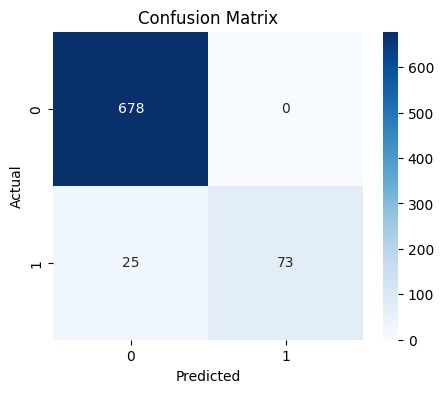

[[678   0]
 [ 25  73]]


In [8]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

print(cm)
# Beklenen yapı:
# [[ham doğru,   ham→spam hata ]
#  [spam→ham hata, spam doğru  ]]

## 8. PyTorch Dataset & DataLoader

In [9]:
import torch
from torch.utils.data import TensorDataset, DataLoader

# Sparse → dense → tensor
X_train_tensor = torch.tensor(X_train_tfidf.toarray(), dtype=torch.float32)
X_val_tensor   = torch.tensor(X_val_tfidf.toarray(),   dtype=torch.float32)
X_test_tensor  = torch.tensor(X_test_tfidf.toarray(),  dtype=torch.float32)

y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32)
y_val_tensor   = torch.tensor(y_val.values,   dtype=torch.float32)
y_test_tensor  = torch.tensor(y_test.values,  dtype=torch.float32)

# Dataset
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset   = TensorDataset(X_val_tensor,   y_val_tensor)
test_dataset  = TensorDataset(X_test_tensor,  y_test_tensor)

# DataLoader
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=32)
test_loader  = DataLoader(test_dataset,  batch_size=32)

print("DataLoader hazır")
print(f"Train batches: {len(train_loader)} | Val batches: {len(val_loader)} | Test batches: {len(test_loader)}")

# Sanity check
X_batch, y_batch = next(iter(train_loader))
print(f"Batch shape: X={X_batch.shape}, y={y_batch.shape}")

DataLoader hazır
Train batches: 114 | Val batches: 25 | Test batches: 25
Batch shape: X=torch.Size([32, 5000]), y=torch.Size([32])


## 9. Spam MLP Modeli (PyTorch)

In [10]:
import torch
import torch.nn as nn
import torch.nn.functional as F

# Giriş: TF-IDF vektör boyutu (üstte max_features=5000 ile üretilen özellikler)
INPUT_DIM = 5000
# Gizli katman boyutları
HIDDEN1, HIDDEN2 = 256, 128

# Cihaz: GPU varsa CUDA, yoksa CPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


class SpamMLP(nn.Module):
    """Binary classification (Ham=0, Spam=1). Çıkış ham logittir; sigmoid yok."""

    def __init__(self, input_dim=INPUT_DIM, hidden1=HIDDEN1, hidden2=HIDDEN2, out_dim=1):
        super().__init__()
        # fc1: 5000 -> 256, fc2: 256 -> 128, fc3: 128 -> 1 (logit)
        self.fc1 = nn.Linear(input_dim, hidden1)
        self.fc2 = nn.Linear(hidden1, hidden2)
        self.fc3 = nn.Linear(hidden2, out_dim)

    def forward(self, x):
        # Gizli katman 1 + ReLU
        x = F.relu(self.fc1(x))
        # Gizli katman 2 + ReLU
        x = F.relu(self.fc2(x))
        # Çıkış: tek nöron, ham logit — Sigmoid EKLEME (sayısal kararlılık: loss içinde)
        logits = self.fc3(x)
        # [batch, 1] -> [batch]; BCEWithLogitsLoss hedef tensörüyle aynı şekil
        return logits.squeeze(-1)


model = SpamMLP().to(device)

# Logits üzerinde BCE; sigmoid kayıp içinde birleşir — overflow riski düşük
criterion = nn.BCEWithLogitsLoss()

optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

print(f"Cihaz: {device}")
print(model)
print(f"Kayıp: {criterion}")
print(f"Optimizatör: Adam (lr=0.001)")

Cihaz: cpu
SpamMLP(
  (fc1): Linear(in_features=5000, out_features=256, bias=True)
  (fc2): Linear(in_features=256, out_features=128, bias=True)
  (fc3): Linear(in_features=128, out_features=1, bias=True)
)
Kayıp: BCEWithLogitsLoss()
Optimizatör: Adam (lr=0.001)


## 10- EĞİTİM DÖNGÜSÜ VE BİLİNÇLİ OVERFITTING (TRAINING LOOP)

In [ ]:
import matplotlib.pyplot as plt

NUM_EPOCHS = 20
train_losses = []
val_losses = []

for epoch in range(NUM_EPOCHS):
    # --- Eğitim ---
    model.train()
    train_running = 0.0
    for X_batch, y_batch in train_loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad(set_to_none=True)
        logits = model(X_batch)
        loss = criterion(logits, y_batch)
        loss.backward()
        optimizer.step()

        train_running += loss.item() * X_batch.size(0)

    train_loss_avg = train_running / len(train_loader.dataset)

    # --- Doğrulama ---
    model.eval()
    val_running = 0.0
    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)
            logits = model(X_batch)
            loss = criterion(logits, y_batch)
            val_running += loss.item() * X_batch.size(0)

    val_loss_avg = val_running / len(val_loader.dataset)

    train_losses.append(train_loss_avg)
    val_losses.append(val_loss_avg)
    print(
        f"Epoch {epoch + 1}/{NUM_EPOCHS} | "
        f"Train Loss: {train_loss_avg:.6f} | Val Loss: {val_loss_avg:.6f}"
    )

# --- Kayıp eğrileri ---
epochs_axis = range(1, NUM_EPOCHS + 1)
plt.figure(figsize=(8, 5))
plt.plot(epochs_axis, train_losses, color="blue", label="Train")
plt.plot(epochs_axis, val_losses, color="red", label="Validation")
plt.xlabel("Epoch")
plt.ylabel("Loss (BCE)")
plt.title("Model Overfitting: Train vs. Validation Loss")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [1]:
print("slm")

slm
